# 01 - Distance Based Methods

## Supervised Learning

Supervised Learning is a type of Machine Learning where a model learns
from **labeled data**.

Each training example contains:

- **Input features (X)** → information used to make a prediction
- **Target/Label (y)** → the correct answer

The goal is to learn a relationship between `X` and `y` so that the model
can make predictions on new, unseen data.

### Example

Suppose we want to predict whether a student will pass an exam.

| Hours Studied | Attendance | Result |
|--------------:|-----------:|--------|
| 2             | 60         | Fail   |
| 4             | 70         | Fail   |
| 6             | 80         | Pass   |
| 8             | 90         | Pass   |

Here:

- `Hours Studied` and `Attendance` are the **features (X)**
- `Result` is the **target (y)**

The model learns from these examples and predicts the result for a
new student.

---

## Main Types of Supervised Learning

Supervised Learning is mainly divided into:

1. **Regression** → predicts a continuous numerical value
2. **Classification** → predicts a category/class

### Regression Example

Predict house price:

```text
Input  → Area, Bedrooms, Location
Output → ₹50,00,000

Input  → Email features
Output → Spam / Not Spam


---

## 2. Import Required Libraries

We will use NumPy for numerical calculations, Pandas for working with
datasets, Matplotlib for visualization, and Scikit-Learn for implementing
machine learning algorithms.

In [85]:
# Import required libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Scikit-Learn
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, mean_squared_error

## 3. What is Distance?

Distance tells us how far two data points are from each other.

For example, consider two points:

- A = (2, 3)
- B = (5, 7)

If the distance between them is small, the points are similar in terms
of their feature values.

Distance is extremely important in distance-based algorithms such as:

- K-Nearest Neighbors (KNN)
- K-Means Clustering
- Recommendation Systems
- Similarity Search

The most commonly used distance is **Euclidean Distance**.

## 4. Euclidean Distance

Euclidean distance is the straight-line distance between two points in a Cartesian plane, derived directly from the Pythagorean theorem.

For two points $A = (x_1, y_1)$ and $B = (x_2, y_2)$, the distance formula is:

$$d(A, B) = \sqrt{(x_2 - x_1)^2 + (y_2 - y_1)^2}$$

---

### Example Calculation

Given two points:
* $A = (2, 3)$
* $B = (5, 7)$

Substitute the coordinates into the formula:

$$
\begin{aligned}
d(A, B) &= \sqrt{(5 - 2)^2 + (7 - 3)^2} \\
        &= \sqrt{3^2 + 4^2} \\
        &= \sqrt{9 + 16} \\
        &= \sqrt{25} \\
        &= 5
\end{aligned}
$$

In [86]:
# Calculate Euclidean distance manually

A = np.array([2, 3])
B = np.array([5, 7])

distance = np.sqrt(np.sum((B - A) ** 2))

print("Euclidean Distance:", distance)

Euclidean Distance: 5.0


## 5. Euclidean Distance Using a Function

Instead of writing the calculation every time, we can create a reusable
function.

In [87]:
def euclidean_distance(point1, point2):
    """
    Calculate the Euclidean distance between two points.
    """
    
    return np.sqrt(np.sum((point1 - point2) ** 2))

In [88]:
# Example

point1 = np.array([2, 3])
point2 = np.array([5, 7])

distance = euclidean_distance(point1, point2)

print("Distance:", distance)

Distance: 5.0


## 6. Visualizing Euclidean Distance

We can visualize two points and the straight-line distance between them.

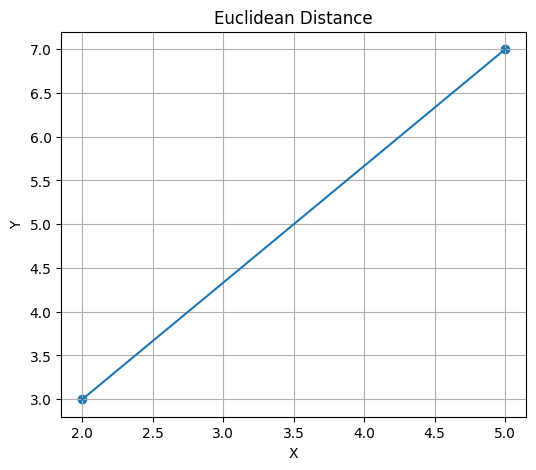

In [89]:
# Points
x = [2, 5]
y = [3, 7]

plt.figure(figsize=(6, 5))

plt.scatter(x, y)

# Draw line between the points
plt.plot(x, y)

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Euclidean Distance")

plt.grid(True)
plt.show()

## 7. Manhattan Distance

Manhattan distance (also known as taxicab or $L_1$ distance) calculates the distance between two points by strictly following horizontal and vertical paths, rather than a direct diagonal line.

For two points $A = (x_1, y_1)$ and $B = (x_2, y_2)$, the formula is:

$$d(A, B) = |x_2 - x_1| + |y_2 - y_1|$$

---

### Example Calculation

Given two points:
* $A = (2, 3)$
* $B = (5, 7)$

Substitute the coordinates into the formula:

$$
\begin{aligned}
d(A, B) &= |5 - 2| + |7 - 3| \\
        &= |3| + |4| \\
        &= 3 + 4 \\
        &= 7
\end{aligned}
$$

In [90]:
def manhattan_distance(point1, point2):
    """
    Calculate Manhattan distance between two points.
    """
    
    return np.sum(np.abs(point1 - point2))

In [91]:
point1 = np.array([2, 3])
point2 = np.array([5, 7])

distance = manhattan_distance(point1, point2)

print("Manhattan Distance:", distance)

Manhattan Distance: 7


## 8. Comparing Distances

In [92]:
point1 = np.array([2, 3])
point2 = np.array([5, 7])

euclidean = euclidean_distance(point1, point2)
manhattan = manhattan_distance(point1, point2)

print("Euclidean Distance:", euclidean)
print("Manhattan Distance:", manhattan)

Euclidean Distance: 5.0
Manhattan Distance: 7


## 9. Minkowski Distance

Minkowski distance is a generalized metric that unifies several common distance metrics into a single parameterized form.

For two points $A = (x_1, x_2, \dots, x_n)$ and $B = (y_1, y_2, \dots, y_n)$ in an $n$-dimensional space, the formula is:

$$d(A, B) = \left( \sum_{i=1}^{n} |x_i - y_i|^p \right)^{\frac{1}{p}}$$

where $p \ge 1$.

---

### Special Cases of $p$

The value assigned to parameter $p$ determines the specific distance metric:

| Value of $p$ | Distance Metric | Formula |
| :--- | :--- | :--- |
| **$p = 1$** | **Manhattan Distance** ($L_1$ norm) | $d(A, B) = \sum_{i=1}^n \|x_i - y_i\|$ |
| **$p = 2$** | **Euclidean Distance** ($L_2$ norm) | $d(A, B) = \sqrt{\sum_{i=1}^n (x_i - y_i)^2}$ |
| **$p \to \infty$** | **Chebyshev Distance** ($L_\infty$ norm) | $d(A, B) = \max_i \|x_i - y_i\|$ |

Euclidean and Manhattan distances are specific instances of the broader Minkowski metric.

In [93]:
def minkowski_distance(point1, point2, p):
    """
    Calculate Minkowski distance between two points.
    """
    
    return np.sum(np.abs(point1 - point2) ** p) ** (1 / p)

In [94]:
point1 = np.array([2, 3])
point2 = np.array([5, 7])

print("p = 1:", minkowski_distance(point1, point2, 1))
print("p = 2:", minkowski_distance(point1, point2, 2))
print("p = 3:", minkowski_distance(point1, point2, 3))

p = 1: 7.0
p = 2: 5.0
p = 3: 4.497941445275415


## 10. Hamming Distance

Hamming Distance measures the number of positions at which two sequences
are different.

It is mainly useful for:

- Binary data
- Categorical data
- Strings
- Error detection

### Example

Consider two binary vectors:

A = [1, 0, 1, 1]

B = [1, 1, 0, 1]

Compare each position:

| Position | A | B | Different? |
|----------|---|---|------------|
| 1        | 1 | 1 | No         |
| 2        | 0 | 1 | Yes        |
| 3        | 1 | 0 | Yes        |
| 4        | 1 | 1 | No         |

Therefore:

\[
Hamming\ Distance = 2
\]

In [95]:
# Hamming Distance

def hamming_distance(point1, point2):
    """
    Calculate Hamming distance between two sequences.
    """
    
    return np.sum(point1 != point2)

In [96]:
# Example

A = np.array([1, 0, 1, 1])
B = np.array([1, 1, 0, 1])

distance = hamming_distance(A, B)

print("Hamming Distance:", distance)

Hamming Distance: 2


## 11. Cosine Similarity

Cosine similarity measures the orientation or direction between two non-zero vectors in an inner product space rather than their magnitude, evaluating how close they point to the same direction based on the cosine of the angle between them.

The mathematical formula is:

$$\text{Cosine Similarity} = \cos(\theta) = \frac{\mathbf{A} \cdot \mathbf{B}}{\|\mathbf{A}\| \|\mathbf{B}\|} = \frac{\sum_{i=1}^n A_i B_i}{\sqrt{\sum_{i=1}^n A_i^2} \sqrt{\sum_{i=1}^n B_i^2}}$$

where:
* $\mathbf{A} \cdot \mathbf{B}$ is the dot product of vectors $\mathbf{A}$ and $\mathbf{B}$
* $\|\mathbf{A}\|$ and $\|\mathbf{B}\|$ are the Euclidean norms (magnitudes) of the vectors

---

### Interpretation of Values

The output ranges between $-1$ and $1$:

$$-1 \le \text{Cosine Similarity} \le 1$$

| Score | Meaning | Vector Relationship |
| :--- | :--- | :--- |
| **$1$** | Exactly identical direction | Parallel ($\theta = 0^\circ$) |
| **$0$** | Orthogonal / Unrelated | Perpendicular ($\theta = 90^\circ$) |
| **$-1$** | Diametrically opposite | Directly opposed ($\theta = 180^\circ$) |

> **Note:** In domains such as Information Retrieval and NLP (e.g., TF-IDF word vectors), vector components are non-negative ($A_i, B_i \ge 0$), restricting the practical range to $[0, 1]$.

---

### Common Applications

* **Natural Language Processing (NLP):** Sentence and document similarity
* **Information Retrieval:** Search query matching against indexed documents
* **Recommendation Systems:** User or item collaborative filtering via preference vectors
* **Plagiarism Detection:** Measuring content overlap between text corpora

In [97]:
# Cosine Similarity

def cosine_similarity(point1, point2):
    """
    Calculate cosine similarity between two vectors.
    """
    
    dot_product = np.dot(point1, point2)
    
    magnitude1 = np.linalg.norm(point1)
    magnitude2 = np.linalg.norm(point2)
    
    return dot_product / (magnitude1 * magnitude2)

In [98]:
# Example

A = np.array([1, 2, 3])
B = np.array([2, 4, 6])

similarity = cosine_similarity(A, B)

print("Cosine Similarity:", similarity)

Cosine Similarity: 1.0


## 12. Distance vs Similarity

Distance and similarity describe relationships between data points in
different ways.

### Distance

Smaller distance means the points are more similar.

```text
Distance ↓
Similarity ↑
Examples:

Euclidean Distance
Manhattan Distance
Minkowski Distance
Hamming Distance
Similarity

Higher similarity means the points are more similar.

Examples:

Cosine Similarity
Simple Comparison
Measure	Better Match
Euclidean Distance	Smaller value
Manhattan Distance	Smaller value
Minkowski Distance	Smaller value
Hamming Distance	Smaller value
Cosine Similarity	Larger value

## 13. Why Feature Scaling is Important

Distance-based algorithms (such as KNN, K-Means, and SVMs with RBF kernels) are highly sensitive to the magnitude and scale of input features. Features measured on larger numerical scales disproportionately dominate distance metrics, causing algorithms to virtually ignore features with smaller ranges.

---

### Motivating Example

Consider two features with different scales:
* **Age:** Ranges from $18$ to $60$ years
* **Salary:** Ranges from $\$20{,}000$ to $\$200{,}000$

Let two data points be:
* Point $A = (20, 30{,}000)$
* Point $B = (25, 50{,}000)$

Using Euclidean distance:

$$
\begin{aligned}
d(A, B) &= \sqrt{(25 - 20)^2 + (50{,}000 - 30{,}000)^2} \\
        &= \sqrt{5^2 + 20{,}000^2} \\
        &= \sqrt{25 + 400{,}000{,}000} \\
        &= \sqrt{400{,}000{,}025} \\
        &\approx 20{,}000.0006
\end{aligned}
$$

The feature difference in age ($5^2 = 25$) is mathematically dwarfed by the salary difference ($20{,}000^2 = 400{,}000{,}000$). The age feature effectively has zero influence on the computed distance.

---

### Common Scaling Solutions

To ensure all features contribute proportionally, apply feature scaling before distance calculations:

| Method | Formula | Range | Best Used When |
| :--- | :--- | :--- | :--- |
| **Min-Max Normalization** | $X_{\text{norm}} = \frac{X - X_{\min}}{X_{\max} - X_{\min}}$ | $[0, 1]$ | Data has bounded ranges with few outliers |
| **Standardization (Z-score)** | $X_{\text{std}} = \frac{X - \mu}{\sigma}$ | $\mu = 0, \sigma = 1$ | Features follow approximately normal distributions |

## 14. Standardization

Standardization (also called Z-score normalization) rescales a feature so that its distribution is centered around a mean of $0$ with a standard deviation of $1$.

The transformation formula is:

$$z = \frac{x - \mu}{\sigma}$$

where:
* $x$ is the original feature value
* $\mu$ is the mean of the feature: $\mu = \frac{1}{N} \sum_{i=1}^{N} x_i$
* $\sigma$ is the standard deviation: $\sigma = \sqrt{\frac{1}{N} \sum_{i=1}^{N} (x_i - \mu)^2}$
* $z$ is the resulting standardized score (Z-score)

---

### Key Properties

* **Centering and Spread:** Guarantees $\mu = 0$ and $\sigma = 1$.
* **Unbounded Output:** Unlike Min-Max scaling, output values are not bounded to a fixed interval like $[0, 1]$; values typically fall within $[-3, 3]$.
* **Outlier Handling:** Less sensitive to extreme values than Min-Max scaling because it does not squash all data into a fixed boundary based on minimum and maximum values.

---

### Scikit-Learn Implementation

```python
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [99]:
# Create sample data

data = np.array([
    [20, 30000],
    [25, 50000],
    [30, 70000],
    [35, 90000],
    [40, 110000]
])

df = pd.DataFrame(
    data,
    columns=["Age", "Salary"]
)

df

,Age,Salary
0,20,30000
1,25,50000
2,30,70000
3,35,90000
4,40,110000


In [100]:
# Create StandardScaler

scaler = StandardScaler()

# Scale the features
scaled_data = scaler.fit_transform(df)

scaled_df = pd.DataFrame(
    scaled_data,
    columns=df.columns
)

scaled_df

,Age,Salary
0,-1.414214,-1.414214
1,-0.707107,-0.707107
2,0.000000,0.000000
3,0.707107,0.707107
4,1.414214,1.414214


## 15. Understanding Standardization

In [101]:
# Check mean after standardization

print("Mean:")
print(scaled_df.mean())

print("\nStandard Deviation:")
print(scaled_df.std(ddof=0))

Mean:
Age       0.000000e+00
Salary   -4.440892e-17
dtype: float64

Standard Deviation:
Age       1.0
Salary    1.0
dtype: float64


## 16. Important Rule: Fit Only on Training Data

When working with real machine learning datasets, we should NOT fit the
scaler using the entire dataset before splitting.

Correct approach:

1. Split data into training and testing sets.
2. Fit the scaler using only training data.
3. Transform training data.
4. Transform testing data using the same scaler.

This prevents information from the test dataset from influencing the
training process.

### Correct Workflow

```text
Original Data
      ↓
Train / Test Split
      ↓
 ┌───────────┐
 │ Training  │ → fit scaler → transform
 └───────────┘

 ┌───────────┐
 │ Testing   │ → transform using same scaler
 └───────────┘

---

# 17. Practical Example of Scaling

In [102]:
from sklearn.datasets import make_classification

# Create a larger classification dataset

X, y = make_classification(
    n_samples=200,
    n_features=2,
    n_redundant=0,
    n_informative=2,
    n_clusters_per_class=1,
    random_state=42
)

In [103]:
# Split the dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [104]:
# Create scaler

scaler = StandardScaler()

# Fit only on training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data
X_test_scaled = scaler.transform(X_test)

print("Scaled Training Data:")
print(X_train_scaled)

print("\nScaled Testing Data:")
print(X_test_scaled)

Scaled Training Data:
[[-5.98696955e-01 -2.16172189e+00]
 [-4.99264109e-01  1.40585459e-01]
 [-1.82277012e+00 -2.29109720e-02]
 [-1.22068580e+00 -1.06225227e+00]
 [-1.18455362e+00  1.01499606e+00]
 [-1.67670128e+00 -1.87378862e+00]
 [ 4.75611227e-01 -3.65517557e-01]
 [ 9.96677034e-01 -4.34811932e-01]
 [-1.52358188e-01  4.58073772e-01]
 [ 1.73422902e+00 -4.69140804e-01]
 [-3.56259772e-02 -3.28703772e-01]
 [ 3.61474819e-01  1.29774824e+00]
 [-1.87272208e-01 -5.14085431e-01]
 [-1.97741822e+00 -1.25606062e+00]
 [-1.64003318e+00 -3.62518909e-01]
 [ 8.62276834e-01 -1.60093671e-01]
 [-1.17729366e-01  6.52731768e-02]
 [ 1.63315958e+00  7.45919235e-01]
 [ 4.43197776e-01 -1.33974825e+00]
 [ 1.14414481e+00 -1.08530884e+00]
 [ 8.21931757e-01  8.60776803e-01]
 [ 7.83093234e-02  2.41076213e-01]
 [ 1.22200067e+00  7.39732048e-01]
 [ 1.41794500e+00  7.29308659e-01]
 [-1.75329500e-01  1.34522558e+00]
 [-9.13825763e-01 -1.39119076e+00]
 [-5.93601150e-01 -1.44038288e+00]
 [ 3.73613470e-01 -6.12002341e-01

# 18. K-Nearest Neighbors (KNN)

K-Nearest Neighbors (KNN) is one of the most important distance-based
Machine Learning algorithms.

The main idea is:

> A data point is likely to belong to the same class as its nearest
> neighbors.

For example, suppose we have two classes:

```text
● ● ●        ▲ ▲ ▲
● ● ●        ▲ ▲ ▲
● ● ?        ▲ ▲ ▲

The ? point is surrounded mainly by ● points.

Therefore, KNN will likely classify ? as class ●.

How KNN Works

Given a new data point:

Choose the value of K.
Calculate the distance from the new point to every training point.
Find the K nearest points.
Look at their classes.
Assign the majority class to the new point.

For classification:

    Prediction = Majority Class of K Neighbors

For regression:

Prediction = Average of K Neighbors

## 19. Simple KNN Example

K-Nearest Neighbors (KNN) classifies an unseen query point by computing its distance to all training points, identifying the $K$ closest instances, and assigning the majority label.

---

### Dataset

Consider a 2D dataset with two classes ($0$ and $1$):

| Point | $X$ | $Y$ | Class |
| :---: | :---: | :---: | :---: |
| **A** | $1.0$ | $1.0$ | $0$ |
| **B** | $2.0$ | $2.0$ | $0$ |
| **C** | $3.0$ | $3.0$ | $1$ |
| **D** | $4.0$ | $4.0$ | $1$ |

**Query Point:** $P = (2.5, 2.5)$  
**Hyperparameter:** $K = 3$

---

### Step 1: Calculate Distances

Using Euclidean distance $d(P, \text{Point}) = \sqrt{(x - 2.5)^2 + (y - 2.5)^2}$:

* **Point A:**
  $$d(P, A) = \sqrt{(1 - 2.5)^2 + (1 - 2.5)^2} = \sqrt{(-1.5)^2 + (-1.5)^2} = \sqrt{2.25 + 2.25} = \sqrt{4.5} \approx 2.12$$

* **Point B:**
  $$d(P, B) = \sqrt{(2 - 2.5)^2 + (2 - 2.5)^2} = \sqrt{(-0.5)^2 + (-0.5)^2} = \sqrt{0.25 + 0.25} = \sqrt{0.5} \approx 0.71$$

* **Point C:**
  $$d(P, C) = \sqrt{(3 - 2.5)^2 + (3 - 2.5)^2} = \sqrt{(0.5)^2 + (0.5)^2} = \sqrt{0.25 + 0.25} = \sqrt{0.5} \approx 0.71$$

* **Point D:**
  $$d(P, D) = \sqrt{(4 - 2.5)^2 + (4 - 2.5)^2} = \sqrt{(1.5)^2 + (1.5)^2} = \sqrt{2.25 + 2.25} = \sqrt{4.5} \approx 2.12$$

---

### Step 2: Rank Distances and Select $K=3$ Neighbors

Sorting points by ascending distance to $P$:

| Rank | Point | Distance | Class | Included in $K=3$? |
| :---: | :---: | :---: | :---: | :---: |
| 1 | **B** | $\approx 0.71$ | $0$ | Yes |
| 2 | **C** | $\approx 0.71$ | $1$ | Yes |
| 3 | **A** (or **D**) | $\approx 2.12$ | $0$ (or $1$) | Tie for 3rd neighbor |

---

### Step 3: Majority Voting & Tie Handling

Because distances to $A$ and $D$ are identical:

* If neighbor **$A$** is selected: classes are $\{0, 1, 0\} \implies$ **Class 0 wins**.
* If neighbor **$D$** is selected: classes are $\{0, 1, 1\} \implies$ **Class 1 wins**.

> **Note on Ties:** In practice, ties can be broken by:
> 1. Selecting an odd value of $K$ that avoids ties among binary classes.
> 2. Using **distance-weighted voting** (weights = $1 / d$), where closer points ($B$ and $C$) carry more weight than distant points ($A$ and $D$).
> 3. Random choice or nearest single neighbor ($K=1$) fallback.

In [105]:
# Training points

X = np.array([
    [1, 1],
    [2, 2],
    [3, 3],
    [4, 4]
])

y = np.array([
    0,
    0,
    1,
    1
])

# New point
new_point = np.array([2.5, 2.5])

# Calculate distance from new point to every training point

distances = []

for point in X:
    distance = euclidean_distance(point, new_point)
    distances.append(distance)

print("Distances:", distances)

Distances: [np.float64(2.1213203435596424), np.float64(0.7071067811865476), np.float64(0.7071067811865476), np.float64(2.1213203435596424)]


## 20. Finding the Nearest Neighbors

In [106]:
# Sort indices according to distance

sorted_indices = np.argsort(distances)

print("Sorted indices:", sorted_indices)
print("Sorted distances:", np.array(distances)[sorted_indices])

Sorted indices: [1 2 0 3]
Sorted distances: [0.70710678 0.70710678 2.12132034 2.12132034]


In [107]:
# Choose K

K = 3

nearest_indices = sorted_indices[:K]

nearest_classes = y[nearest_indices]

print("Nearest indices:", nearest_indices)
print("Nearest classes:", nearest_classes)

Nearest indices: [1 2 0]
Nearest classes: [0 1 0]


## 21. Majority Voting

In [108]:
# Count occurrences of each class

classes, counts = np.unique(
    nearest_classes,
    return_counts=True
)

prediction = classes[np.argmax(counts)]

print("Predicted Class:", prediction)

Predicted Class: 0


## 22. KNN Classification with Scikit-Learn

Instead of implementing KNN manually, we can use Scikit-Learn's
`KNeighborsClassifier`.

The basic process is:

```text
Dataset
   ↓
Train/Test Split
   ↓
Feature Scaling
   ↓
Create KNN Model
   ↓
Train Model
   ↓
Make Predictions
   ↓
Evaluate Model

In [109]:
# Create KNN classifier

knn_model = KNeighborsClassifier(
    n_neighbors=3
)

# Train the model
knn_model.fit(
    X_train_scaled,
    y_train
)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [110]:
# Make predictions

y_pred = knn_model.predict(X_test_scaled)

print("Predictions:", y_pred)
print("Actual:", y_test)

Predictions: [0 0 1 0 1 1 0 0 0 0 0 0 1 1 0 1 0 0 1 1 1 0 1 0 0 0 0 0 0 1 0 1 0 0 0 0 1
 0 1 0]
Actual: [0 0 0 1 1 1 0 0 0 0 0 0 1 1 0 1 0 0 1 1 1 1 1 0 0 0 0 0 0 1 0 1 0 0 1 0 1
 0 1 1]


In [111]:
# Calculate accuracy

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:", accuracy)

Accuracy: 0.875


## 23. Choosing the Value of K

The value of `K` represents the number of nearest neighbors considered
when making a prediction.

For example:

- K = 1 → use 1 nearest neighbor
- K = 3 → use 3 nearest neighbors
- K = 5 → use 5 nearest neighbors

The choice of `K` affects the behavior of the model.

### Small K

A very small value of K can make the model sensitive to individual
data points and noise.

This can lead to **overfitting**.

### Large K

A very large value of K makes the model consider many points.

This can make the model too simple and may lead to **underfitting**.

### General Idea

```text
Small K  → More complex model → Possible overfitting

Large K  → Simpler model      → Possible underfitting

# 24. Testing Different Values of K

In [112]:
# Test different K values

k_values = range(1, 11)

accuracies = []

for k in k_values:
    
    model = KNeighborsClassifier(
        n_neighbors=k
    )
    
    model.fit(
        X_train_scaled,
        y_train
    )
    
    predictions = model.predict(
        X_test_scaled
    )
    
    accuracy = accuracy_score(
        y_test,
        predictions
    )
    
    accuracies.append(accuracy)

print("K values:", list(k_values))
print("Accuracies:", accuracies)    

K values: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Accuracies: [0.825, 0.85, 0.875, 0.875, 0.95, 0.95, 0.925, 0.9, 0.85, 0.85]


## 25. Plot K vs Accuracy

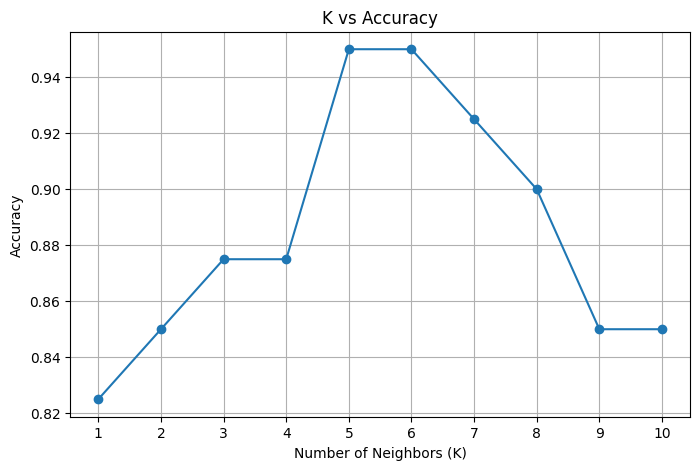

In [113]:
plt.figure(figsize=(8, 5))

plt.plot(
    k_values,
    accuracies,
    marker="o"
)

plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Accuracy")
plt.title("K vs Accuracy")

plt.xticks(list(k_values))
plt.grid(True)

plt.show()

### Observation

The accuracy can change as `K` changes.

We should not simply assume that:

```text
K = 1
or

K = 5

is always the best choice.

Instead, we evaluate different values of K and select an appropriate
value based on validation performance.


---

## 26. Why Odd Values of K Are Often Used

In binary classification, odd values of `K` are often preferred because
they reduce the possibility of a tie during majority voting.

For example:

### K = 4

```text
Class 0 → 2
Class 1 → 2
This results in a tie.

K = 5
Class 0 → 3
Class 1 → 2

There is a clear majority.

However, using an odd value is not a strict requirement.
A suitable value should ultimately be selected based on model
performance and the characteristics of the dataset.


---

# 27. KNN Decision Boundary

A decision boundary shows how a classification model divides the
feature space into different classes.

KNN creates a flexible decision boundary because predictions depend
on nearby training points.

We can visualize this using a simple two-dimensional dataset.

In [114]:
from sklearn.datasets import make_classification

# Generate a simple classification dataset

X, y = make_classification(
    n_samples=200,
    n_features=2,
    n_redundant=0,
    n_informative=2,
    n_clusters_per_class=1,
    random_state=42
)

X[:5], y[:5]

(array([[-0.87292898,  0.013042  ],
        [ 1.31293463,  2.77053357],
        [ 2.34042818,  2.42099601],
        [ 2.29454774, -0.40438019],
        [ 0.94410516,  0.4772409 ]]),
 array([1, 1, 1, 1, 1]))

## 28. Visualize the Dataset

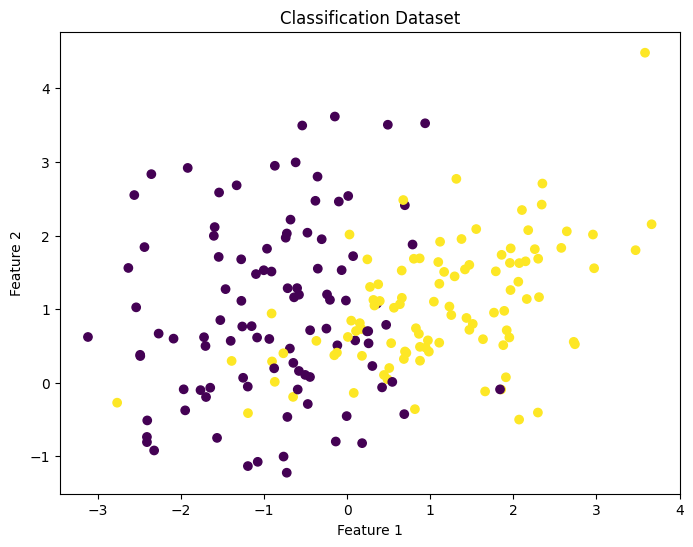

In [115]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=y
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Classification Dataset")

plt.show()

## 29. Train KNN on the Dataset

In [116]:
# Split data

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Scale the features

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Create KNN model

knn = KNeighborsClassifier(
    n_neighbors=5
)

# Train

knn.fit(
    X_train_scaled,
    y_train
)

# Predict

y_pred = knn.predict(
    X_test_scaled
)

# Evaluate

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:", accuracy)

Accuracy: 0.95


# 30. KNN From Scratch

Now we will implement KNN ourselves.

This helps us understand what happens internally instead of treating
KNN as a black-box algorithm.

Our implementation will:

1. Store the training data.
2. Calculate distances.
3. Find the nearest neighbors.
4. Perform majority voting.
5. Return predictions.

In [117]:
class KNNFromScratch:
    
    def __init__(self, k=3):
        self.k = k
    
    def fit(self, X, y):
        """
        Store training data.
        """
        self.X_train = X
        self.y_train = y
        
        return self
    
    def predict(self, X):
        """
        Predict classes for new data.
        """
        
        predictions = []
        
        for point in X:
            
            # Calculate distances
            distances = np.sqrt(
                np.sum(
                    (self.X_train - point) ** 2,
                    axis=1
                )
            )
            
            # Find nearest neighbors
            nearest_indices = np.argsort(distances)[:self.k]
            
            # Get their classes
            nearest_classes = self.y_train[nearest_indices]
            
            # Majority voting
            classes, counts = np.unique(
                nearest_classes,
                return_counts=True
            )
            
            prediction = classes[np.argmax(counts)]
            
            predictions.append(prediction)
        
        return np.array(predictions)

## 31. Test Our KNN Implementation

In [118]:
# Create our KNN model

knn_scratch = KNNFromScratch(k=5)

# Train

knn_scratch.fit(
    X_train_scaled,
    y_train
)

# Predict

scratch_predictions = knn_scratch.predict(
    X_test_scaled
)

print("Predictions:")
print(scratch_predictions)

Predictions:
[0 1 1 1 1 1 0 0 0 0 0 0 1 1 0 1 0 0 1 1 1 1 1 0 0 0 0 0 0 1 0 1 0 0 1 0 1
 0 1 1]


## 32. Evaluate KNN From Scratch

In [119]:
scratch_accuracy = accuracy_score(
    y_test,
    scratch_predictions
)

print("KNN From Scratch Accuracy:", scratch_accuracy)

KNN From Scratch Accuracy: 0.95


Our implementation follows the same basic idea used by the
Scikit-Learn KNN classifier:

```text
New Point
    ↓
Calculate Distance
    ↓
Sort Distances
    ↓
Select K Neighbors
    ↓
Majority Voting
    ↓
Prediction

## 33. KNN Regression

K-Nearest Neighbors can be extended directly to continuous regression problems. While classification predicts a discrete class label using majority voting, regression predicts a continuous real-valued target by aggregating the values of the $K$ nearest neighbors.

---

### Classification vs. Regression

| Task | Aggregation Strategy | Mathematical Formulation |
| :--- | :--- | :--- |
| **Classification** | Majority Voting (Mode) | $\hat{y} = \operatorname{mode}(y_1, y_2, \dots, y_K)$ |
| **Regression (Uniform)** | Arithmetic Mean | $\hat{y} = \frac{1}{K} \sum_{i=1}^K y_i$ |
| **Regression (Distance-Weighted)** | Weighted Average | $\hat{y} = \frac{\sum_{i=1}^K w_i y_i}{\sum_{i=1}^K w_i}, \quad \text{where } w_i = \frac{1}{d_i}$ |

---

### Example Calculation

Suppose an unseen house needs a price prediction, and $K = 3$. The 3 nearest neighboring houses have the following target sale prices:

* $y_1 = \text{₹}40\text{ lakh}$
* $y_2 = \text{₹}45\text{ lakh}$
* $y_3 = \text{₹}50\text{ lakh}$

Using the uniform mean:

$$\begin{aligned} \hat{y} &= \frac{1}{3} (40 + 45 + 50) \\         &= \frac{135}{3} \\         &= 45\text{ lakh} \end{aligned}$$

The predicted price for the query point is **₹45 lakh**.

---

### Scikit-Learn Implementation

```python
from sklearn.neighbors import KNeighborsRegressor

# weights='uniform' (default) or weights='distance'
regressor = KNeighborsRegressor(n_neighbors=3, weights='uniform')
regressor.fit(X_train, y_train)

# Predict continuous target values
y_pred = regressor.predict(X_test)

---

# 34. Simple KNN Regression Example

In [123]:
X = np.array([
    [1],
    [2],
    [3],
    [4],
    [5],
    [6]
])

y = np.array([
    10,
    20,
    30,
    40,
    50,
    60
])

In [124]:
# Create KNN Regressor

knn_regressor = KNeighborsRegressor(
    n_neighbors=3
)

# Train

knn_regressor.fit(
    X,
    y
)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [125]:
# Make a prediction

new_value = np.array([
    [3.5]
])

prediction = knn_regressor.predict(
    new_value
)

print("Predicted value:", prediction[0])

Predicted value: 30.0


## 35. KNN Regression With Train/Test Split

In [126]:
# Create a larger dataset

X = np.arange(1, 21).reshape(-1, 1)

y = 2 * X.flatten() + 5

print("X:")
print(X[:5])

print("\ny:")
print(y[:5])

X:
[[1]
 [2]
 [3]
 [4]
 [5]]

y:
[ 7  9 11 13 15]


In [127]:
# Split dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [128]:
# Scale the data

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [129]:
# Create KNN regression model

knn_regressor = KNeighborsRegressor(
    n_neighbors=3
)

# Train

knn_regressor.fit(
    X_train_scaled,
    y_train
)

# Predict

y_pred = knn_regressor.predict(
    X_test_scaled
)

print("Predicted values:")
print(y_pred)

print("\nActual values:")
print(y_test)

Predicted values:
[13.         42.33333333 35.66666667 13.        ]

Actual values:
[ 7 41 37  9]


## 36. Evaluate KNN Regression

For regression, we cannot use classification accuracy.

One commonly used metric is **Mean Squared Error (MSE)**.

$$MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

Lower MSE generally means better predictions.

In [130]:
mse = mean_squared_error(
    y_test,
    y_pred
)

print("Mean Squared Error:", mse)

Mean Squared Error: 13.888888888888893


# 37. Important Characteristics of KNN

### Advantages

- Simple to understand
- Easy to implement
- No complicated training process
- Can be used for classification and regression
- Works well for some small and medium-sized datasets

### Disadvantages

- Prediction can be computationally expensive
- Sensitive to feature scaling
- Sensitive to irrelevant features
- Performance can decrease with high-dimensional data
- Requires storing the training dataset

### Important

KNN is often called a **lazy learning algorithm** because it does not
learn a complex model during training.

Most of the computational work happens when making predictions.

# 38. Summary

In this notebook, we learned:

### Supervised Learning

Learning from labeled data.

### Distance Measures

- Euclidean Distance
- Manhattan Distance
- Minkowski Distance
- Hamming Distance
- Cosine Similarity

### Feature Scaling

Distance-based algorithms are sensitive to feature scale, so scaling
is often necessary.

### KNN

KNN predicts a new point using its nearest neighbors.

For classification:


Prediction = Majority Vote


For regression:


Prediction = Mean of Neighbors


### KNN Workflow

```text
Dataset
   ↓
Train/Test Split
   ↓
Feature Scaling
   ↓
Choose K
   ↓
Calculate Distances
   ↓
Find K Nearest Neighbors
   ↓
Prediction
   ↓
Evaluation